The data-driven approach of kNN is limited by memory and computation time because it requires storing all training data and comparing each new image to the entire dataset during inference. While training is very fast, testing is slow and expensive. To address this, it is better to compress the information contained in the training data and use this compressed representation for inference. One parametric approach is the linear classifier. The intuition is that instead of saying, “To classify this cat image, compare it to 10,000 previous cat images,” we say, “Learn what makes a cat look like a cat and store that knowledge in parameters.” This shift from lazy, instance-based learners like kNN to eager, model-based learning enables better scaling and generalization.

Epoch   0 | loss: 2.4084
Epoch  20 | loss: 0.3685
Epoch  40 | loss: 0.2349
Epoch  60 | loss: 0.1876
Epoch  80 | loss: 0.1606
Epoch 100 | loss: 0.1426
Epoch 120 | loss: 0.1296
Epoch 140 | loss: 0.1195
Epoch 160 | loss: 0.1115
Epoch 180 | loss: 0.1049

Train accuracy: 0.9798
Test  accuracy: 0.9028


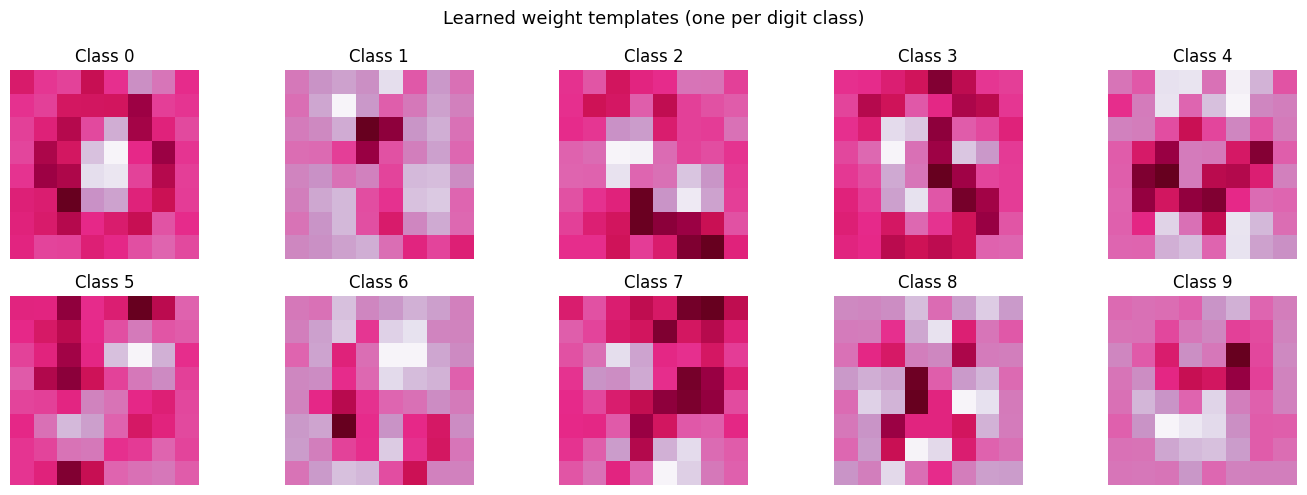

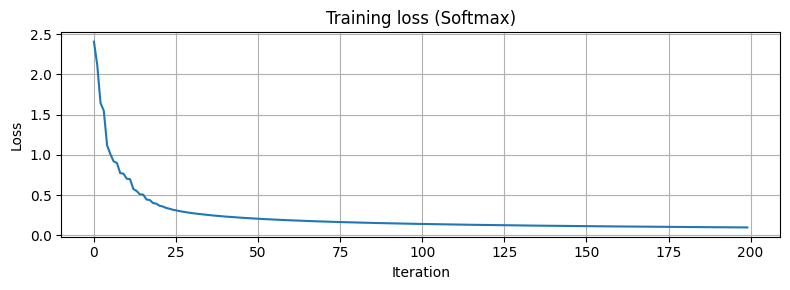

In [8]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

#1. data loading
digits = load_digits()
X, y = digits.data, digits.target         


#append a column of 1s so we only need W (no separate b in y_h = Wx + b)
X = np.hstack([X, np.ones((X.shape[0], 1))])   

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

N, D = X_train.shape          
C = len(np.unique(y))      


#2. loss functions
def svm_loss(W, X, y, reg=1e-3):
    """
    Multiclass SVM (hinge) loss.
    """
    N = X.shape[0]
    scores = X @ W                                      

    correct = scores[np.arange(N), y].reshape(-1, 1)    
    margins = np.maximum(0, scores - correct + 1)        
    margins[np.arange(N), y] = 0                         

    loss = margins.sum() / N + reg * np.sum(W * W)

    # gradient
    mask = (margins > 0).astype(float)
    mask[np.arange(N), y] -= mask.sum(axis=1)
    dW = X.T @ mask / N + 2 * reg * W       

    return loss, dW


def softmax_loss(W, X, y, reg=1e-3):
    """
    Softmax (cross-entropy) loss.
    """
    N = X.shape[0]
    scores = X @ W                                     

    # numerical stability: subtract row-max before exp
    scores -= scores.max(axis=1, keepdims=True)
    exp_s = np.exp(scores)
    probs = exp_s / exp_s.sum(axis=1, keepdims=True)  # (N, C)

    loss = -np.log(probs[np.arange(N), y]).mean() + reg * np.sum(W * W)

    # gradient
    dscores = probs.copy()
    dscores[np.arange(N), y] -= 1
    dW = X.T @ dscores / N + 2 * reg * W

    return loss, dW


#3. linear classifier
class LinearClassifier:
    def __init__(self, loss_fn="svm_loss", lr=1e-3, reg=1e-3,
                 epochs=2000):
        self.loss_fn = softmax_loss if loss_fn == "softmax" else svm_loss
        self.lr = lr
        self.reg = reg
        self.epochs = epochs
        self.history = []

    def fit(self, X, y):
        N, D = X.shape
        C = len(np.unique(y))
        # small random initialization
        self.W = 0.01 * np.random.randn(D, C)

        for epoch in range(self.epochs):
            loss, dW = self.loss_fn(self.W, X, y, self.reg)
            
            # update weights
            self.W  -= self.lr * dW
            self.history.append(loss)

            if epoch % 20 == 0:
                print(f"Epoch {epoch:3d} | loss: {loss:.4f}")

        return self

    def predict(self, X):
        scores = X @ self.W                  
        return scores.argmax(axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)


#4. training&evaluation
clf = LinearClassifier(loss_fn="softmax", lr=1e-2, reg=1e-3, epochs=200)
clf.fit(X_train, y_train)

print(f"\nTrain accuracy: {clf.accuracy(X_train, y_train):.4f}")
print(f"Test  accuracy: {clf.accuracy(X_test,  y_test):.4f}")


#5. visualizing learned weights
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
fig.suptitle("Learned weight templates (one per digit class)", fontsize=13)

for c, ax in enumerate(axes.flat):
    # drop the bias weight, reshape to 8×8 image
    w_img = clf.W[:-1, c].reshape(8, 8)
    ax.imshow(w_img, cmap="PuRd")
    ax.set_title(f"Class {c}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# loss curve
plt.figure(figsize=(8, 3))
plt.plot(clf.history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss (Softmax)")
plt.grid(True)
plt.tight_layout()
plt.show()

The weights visualized above represent the learned “templates” for each class. The model compares the input image with these templates by multiplying each input pixel by its corresponding weight and summing the results to produce a class score for each digit. It is clear that the model has learned the basic underlying representation of digits such as 0, 2, and 5. For example, for the digit 0, the pixels forming the circular ring are assigned larger weights than pixels in other regions, allowing the classifier to recognize the characteristic shape of the digit.